Figures saved to:
/home/phd2/Scrivania/CorsoRepo/blasto_prediction/_09_test/output_manual/comparison_auc_f1_barplot_vertical.png
/home/phd2/Scrivania/CorsoRepo/blasto_prediction/_09_test/output_manual/comparison_auc_f1_barplot_vertical.svg


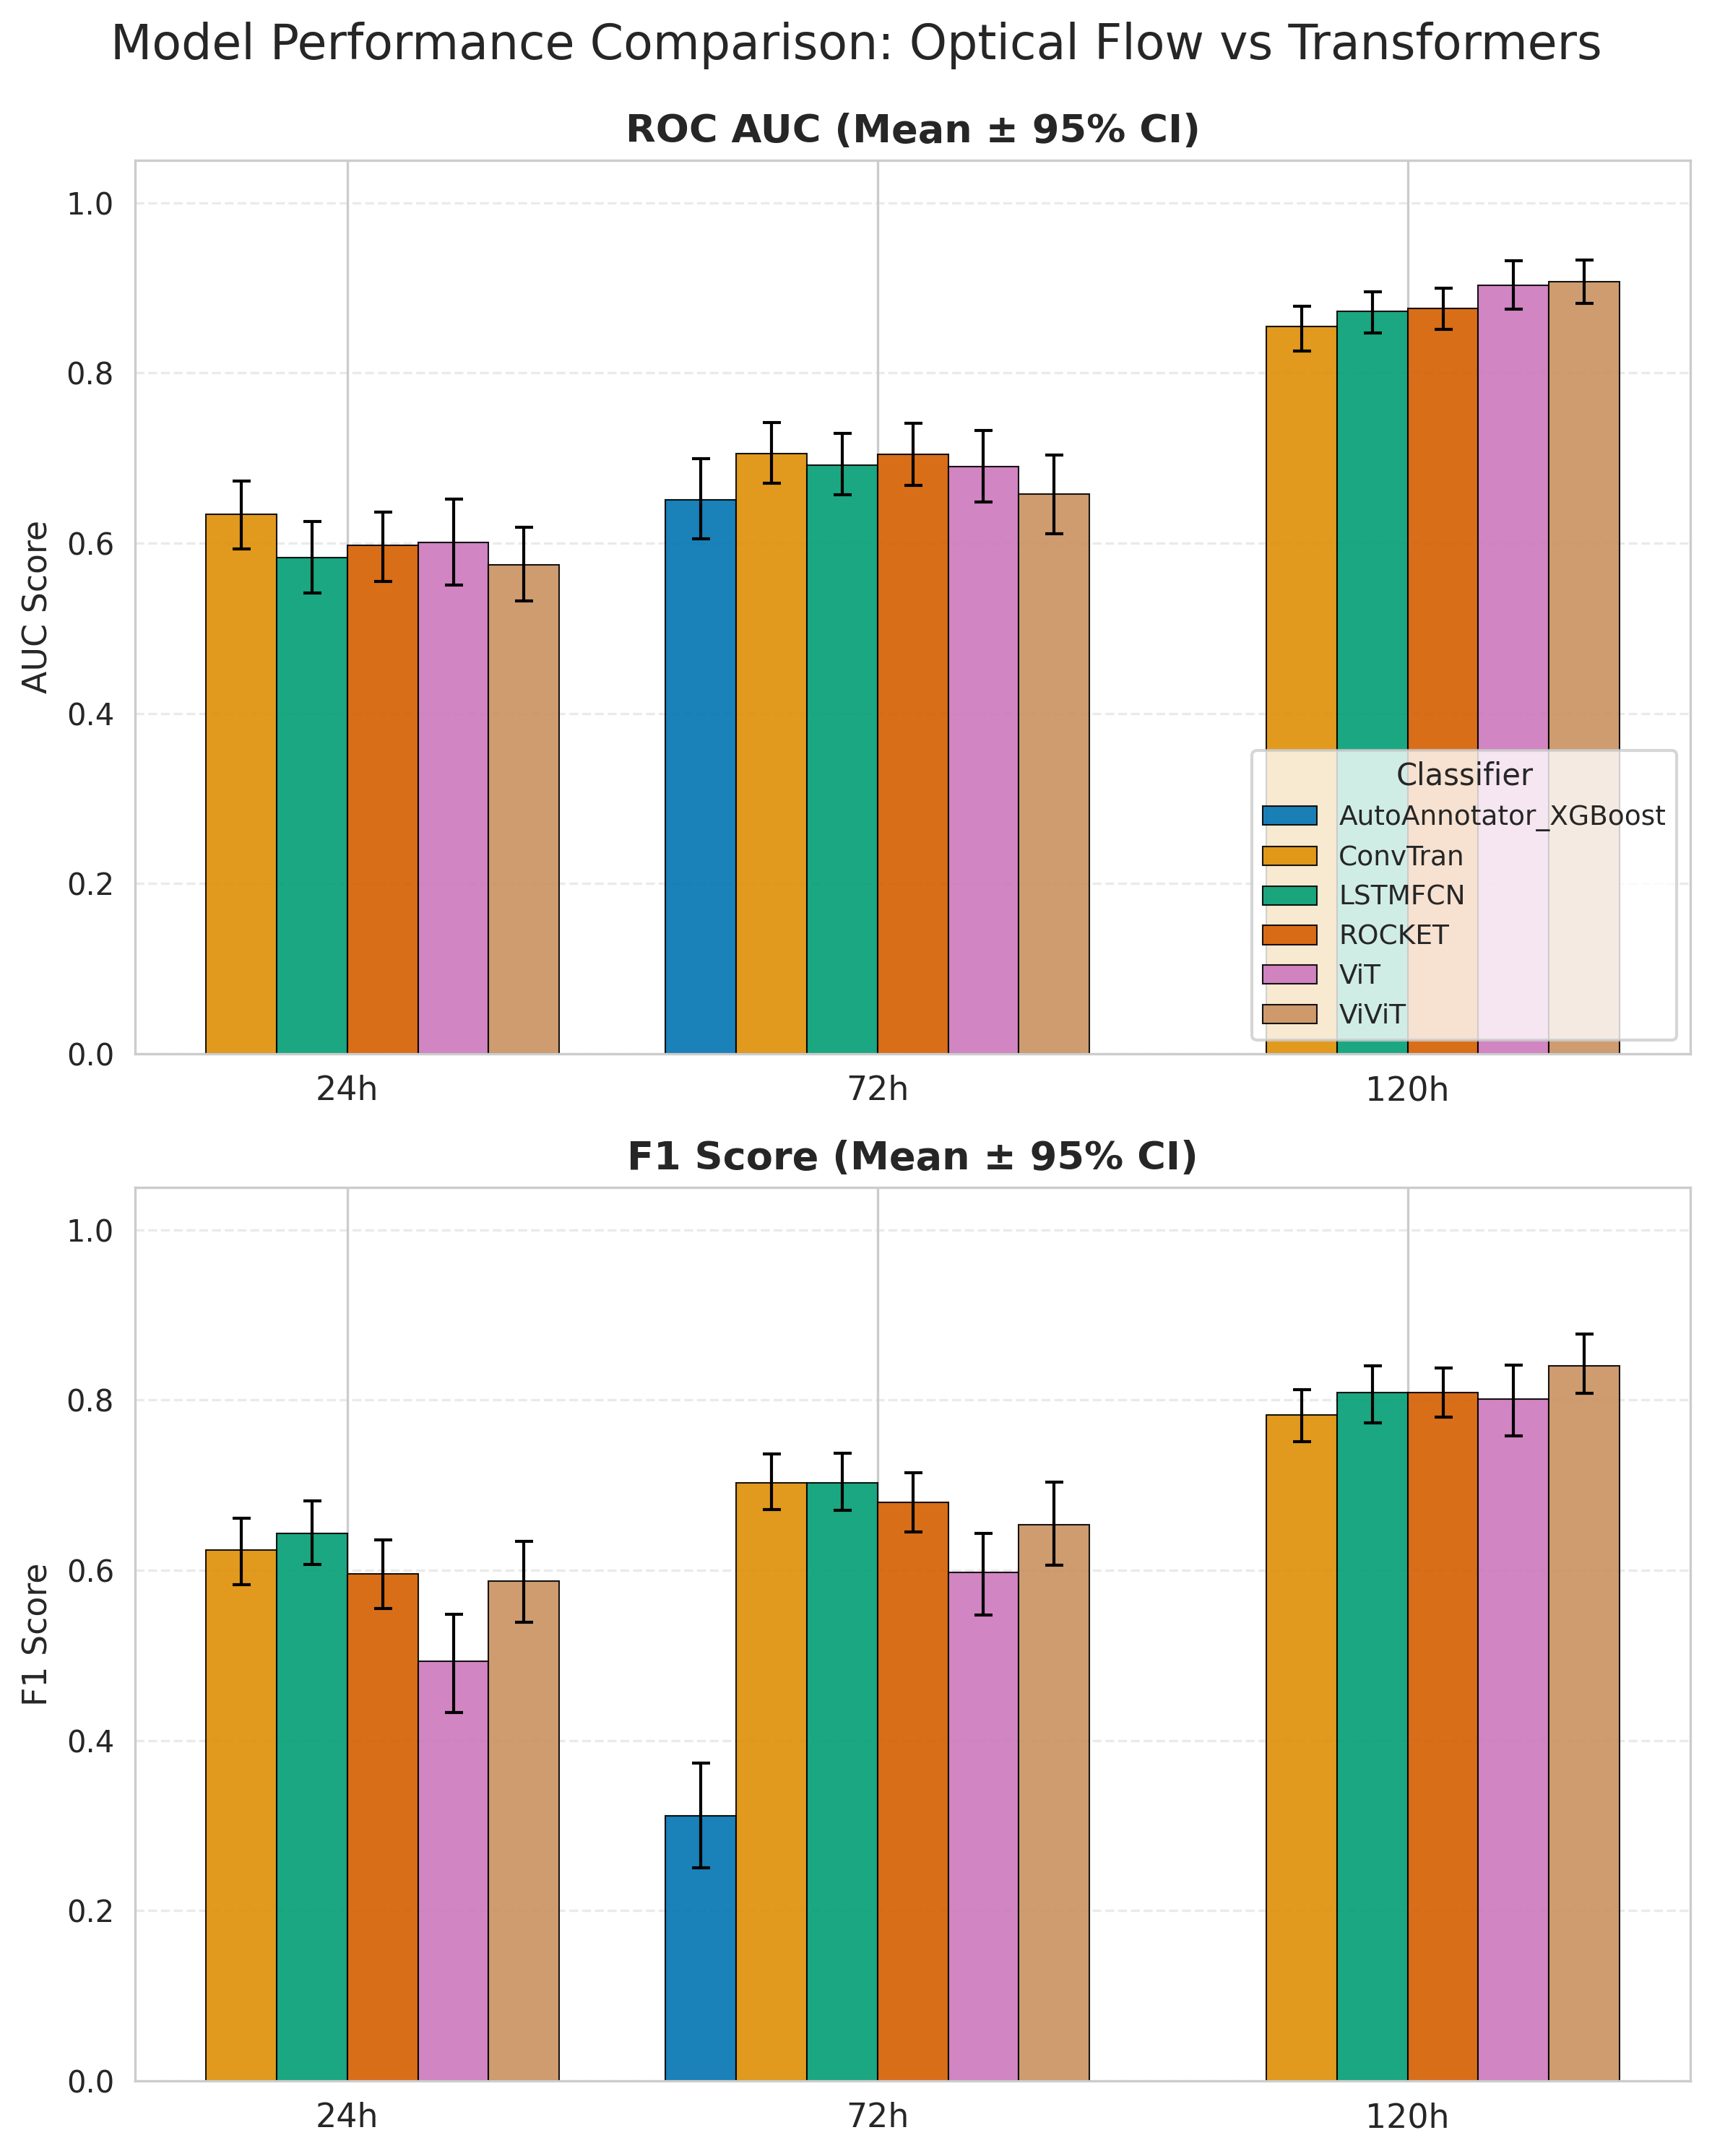

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Load the data
path_to_csv = "/home/phd2/Scrivania/CorsoRepo/blasto_prediction/_09_test/output_manual/.csv"
# Assuming the file exists at the path, otherwise typical usage:
df = pd.read_csv(path_to_csv)

# 2. Setup Plotting Variables
plot_hours = sorted(list(set(df['hours'].tolist())))
plot_clfs = sorted(list(set(df['classifier'].tolist())))

# Ensure consistent color mapping (colorblind palette)
palette = sns.color_palette("colorblind", n_colors=len(plot_clfs))
color_map = {clf: palette[i] for i, clf in enumerate(plot_clfs)}

# 3. Data Extraction Logic
def get_metric_data(mean_col, ci_low_col, ci_high_col):
    """
    Extracts data for a specific metric into (n_clfs, n_hours) matrices.
    """
    means_matrix = []
    ci_lo_matrix = []
    ci_hi_matrix = []

    for clf in plot_clfs:
        m_row, l_row, h_row = [], [], []
        for hr in plot_hours:
            # Filter for specific classifier and hour
            row = df[(df['classifier'] == clf) & (df['hours'] == hr)]
            
            if not row.empty:
                r = row.iloc[0]
                m_row.append(float(r[mean_col]))
                l_row.append(float(r[ci_low_col]))
                h_row.append(float(r[ci_high_col]))
            else:
                m_row.append(np.nan)
                l_row.append(np.nan)
                h_row.append(np.nan)
        
        means_matrix.append(m_row)
        ci_lo_matrix.append(l_row)
        ci_hi_matrix.append(h_row)

    return np.array(means_matrix), np.array(ci_lo_matrix), np.array(ci_hi_matrix)

# Extract AUC data
auc_means, auc_lo_abs, auc_hi_abs = get_metric_data('auc_mean', 'auc_ci_low', 'auc_ci_high')

# Extract F1 data
f1_means, f1_lo_abs, f1_hi_abs = get_metric_data('f1_mean', 'f1_ci_low', 'f1_ci_high')

# 4. Convert Absolute CIs to Relative Error Lengths for Matplotlib
def ci_to_err(mean_arr, lo_arr, hi_arr):
    err_lo = mean_arr - lo_arr
    err_hi = hi_arr - mean_arr
    return err_lo, err_hi

auc_err_lo, auc_err_hi = ci_to_err(auc_means, auc_lo_abs, auc_hi_abs)
f1_err_lo, f1_err_hi = ci_to_err(f1_means, f1_lo_abs, f1_hi_abs)

# 5. Plotting
n_hours = len(plot_hours)
n_clfs = len(plot_clfs)
x = np.arange(n_hours)

# Bar sizing logic
total_width = 0.8
bar_width = total_width / max(1, n_clfs)
offsets = np.linspace(-total_width/2 + bar_width/2, total_width/2 - bar_width/2, n_clfs)

# --- CHANGE HERE: 2 Rows, 1 Column, Taller Figure Size ---
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharey=True)

# --- Subplot 1: ROC AUC (Top) ---
ax = axes[0]
for i, clf in enumerate(plot_clfs):
    means = auc_means[i]
    lo = auc_err_lo[i]
    hi = auc_err_hi[i]
    
    xs = x + offsets[i]
    mask = ~np.isnan(means)
    
    if mask.any():
        ax.bar(xs[mask], means[mask], width=bar_width, label=clf, 
               color=color_map[clf], edgecolor="k", linewidth=0.5, alpha=0.9)
        # capsize adds the little horizontal lines at the top of error bars
        ax.errorbar(xs[mask], means[mask], yerr=[lo[mask], hi[mask]], 
                    fmt='none', ecolor='k', capsize=3, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in plot_hours], fontsize=11)
ax.set_title("ROC AUC (Mean ± 95% CI)", fontsize=13, fontweight='bold')
ax.set_ylim(0.0, 1.05) 
ax.set_ylabel("AUC Score", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='lower right', title="Classifier", fontsize=9)

# --- Subplot 2: F1 Score (Bottom) ---
ax = axes[1]
for i, clf in enumerate(plot_clfs):
    means = f1_means[i]
    lo = f1_err_lo[i]
    hi = f1_err_hi[i]
    
    xs = x + offsets[i]
    mask = ~np.isnan(means)
    
    if mask.any():
        ax.bar(xs[mask], means[mask], width=bar_width, label=clf, 
               color=color_map[clf], edgecolor="k", linewidth=0.5, alpha=0.9)
        ax.errorbar(xs[mask], means[mask], yerr=[lo[mask], hi[mask]], 
                    fmt='none', ecolor='k', capsize=3, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels([f"{h}h" for h in plot_hours], fontsize=11)
ax.set_title("F1 Score (Mean ± 95% CI)", fontsize=13, fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("F1 Score", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Layout adjustments
plt.suptitle("Model Performance Comparison: Optical Flow vs Transformers", fontsize=16, y=0.99)
plt.tight_layout() # Adjust rect to make room for suptitle

# 6. Save Outputs
out_path_save = "/home/phd2/Scrivania/CorsoRepo/blasto_prediction/_09_test/output_manual"
# Ensure directory exists just in case
os.makedirs(out_path_save, exist_ok=True)

# Changed filenames slightly to indicate vertical layout
png_path = os.path.join(out_path_save, "comparison_auc_f1_barplot_vertical.png")
svg_path = os.path.join(out_path_save, "comparison_auc_f1_barplot_vertical.svg")

fig.savefig(png_path, dpi=300, bbox_inches='tight')
fig.savefig(svg_path, dpi=300, bbox_inches='tight')

print(f"Figures saved to:\n{png_path}\n{svg_path}")
plt.show()